## 1. Instalación de librerías

In [1]:
#!pip install torch torchvision timm pillow matplotlib

## 2. Importar librerías

In [2]:
import torch
import timm
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 3. Modelo preentrenado
Usamos mobilenetv3_small_050.lamb_in1k

In [3]:
MODEL_NAME = "mobilenetv3_small_050.lamb_in1k"

modelo = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1000)
modelo.eval()
modelo.to(device)
config = timm.data.resolve_data_config({}, model=modelo)
transformar = timm.data.create_transform(**config)

print(f"Modelo '{MODEL_NAME}' cargado.")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.2f}M")
print(f"Config de preprocesamiento: {config}")

Modelo 'mobilenetv3_small_050.lamb_in1k' cargado.
Parámetros: 1.59M
Config de preprocesamiento: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}


## 4. Etiquetas de ImageNet

In [4]:
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
etiquetas = urllib.request.urlopen(LABELS_URL).read().decode("utf-8").splitlines()
print(f"Total de etiquetas cargadas: {len(etiquetas)}")

Total de etiquetas cargadas: 1000


## 5. Imágenes de prueba

In [5]:

rutas_imagenes = [
    "images/prueba1.jpg",
    "images/prueba2.jpg",
    "images/prueba3.jpg",
]

## 6. Función de predicción

In [6]:
def predecir(ruta_imagen, top_k=5):
    imagen = Image.open(ruta_imagen).convert("RGB")
    entrada = transformar(imagen).unsqueeze(0).to(device)

    with torch.no_grad():
        salida = modelo(entrada)
        probabilidades = torch.nn.functional.softmax(salida[0], dim=0)

    top_prob, top_idx = torch.topk(probabilidades, top_k)
    resultados = [(etiquetas[idx], prob.item()) for prob, idx in zip(top_prob, top_idx)]
    return imagen, resultados

In [7]:
class GradCAM:
    """Calcula el mapa de calor Grad-CAM a partir de la última capa convolucional.

    Usa retain_grad() sobre el propio tensor de activación en lugar de un
    backward hook, porque MobileNetV3 aplica una activación Hardswish
    in-place justo después de la capa objetivo y eso rompe los backward
    hooks (RuntimeError: view is being modified inplace).
    """

    def __init__(self, modelo, capa_objetivo):
        self.modelo = modelo
        self.activaciones = None
        capa_objetivo.register_forward_hook(self._guardar_activaciones)

    def _guardar_activaciones(self, module, entrada, salida):
        self.activaciones = salida
        # El mismo hook también se dispara dentro de predecir(), que corre
        # bajo torch.no_grad(); ahí no hay grafo y retain_grad() fallaría.
        if salida.requires_grad:
            salida.retain_grad()

    def generar(self, entrada, clase_idx=None):
        salida = self.modelo(entrada)
        if clase_idx is None:
            clase_idx = salida.argmax(dim=1).item()

        self.modelo.zero_grad()
        salida[0, clase_idx].backward()

        gradientes = self.activaciones.grad
        pesos = gradientes.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((pesos * self.activaciones).sum(dim=1)).squeeze(0)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy(), clase_idx


capa_objetivo = [m for m in modelo.modules() if isinstance(m, torch.nn.Conv2d)][-1]
grad_cam = GradCAM(modelo, capa_objetivo)
print(f"Capa objetivo para Grad-CAM: {capa_objetivo}")


def generar_heatmap(ruta_imagen):
    imagen = Image.open(ruta_imagen).convert("RGB")
    entrada = transformar(imagen).unsqueeze(0).to(device)

    cam, _ = grad_cam.generar(entrada)

    cam_img = Image.fromarray(np.uint8(cam * 255)).resize(imagen.size, resample=Image.BICUBIC)
    heatmap = np.array(cam_img) / 255.0
    return imagen, heatmap

Capa objetivo para Grad-CAM: Conv2d(288, 1024, kernel_size=(1, 1), stride=(1, 1))


## 8. Clasificador y visualizar resultados


Imagen: images/prueba1.jpg
  golden retriever          87.62%
  Norfolk terrier            1.31%
  Labrador retriever         0.82%
  kuvasz                     0.67%
  Tibetan mastiff            0.39%

Imagen: images/prueba2.jpg
  malamute                  24.19%
  Eskimo dog                17.33%
  Arctic fox                 7.59%
  Siberian husky             6.48%
  collie                     1.72%

Imagen: images/prueba3.jpg
  banana                    48.87%
  consomme                   6.90%
  spaghetti squash           5.80%
  maraca                     3.21%
  spotlight                  1.36%


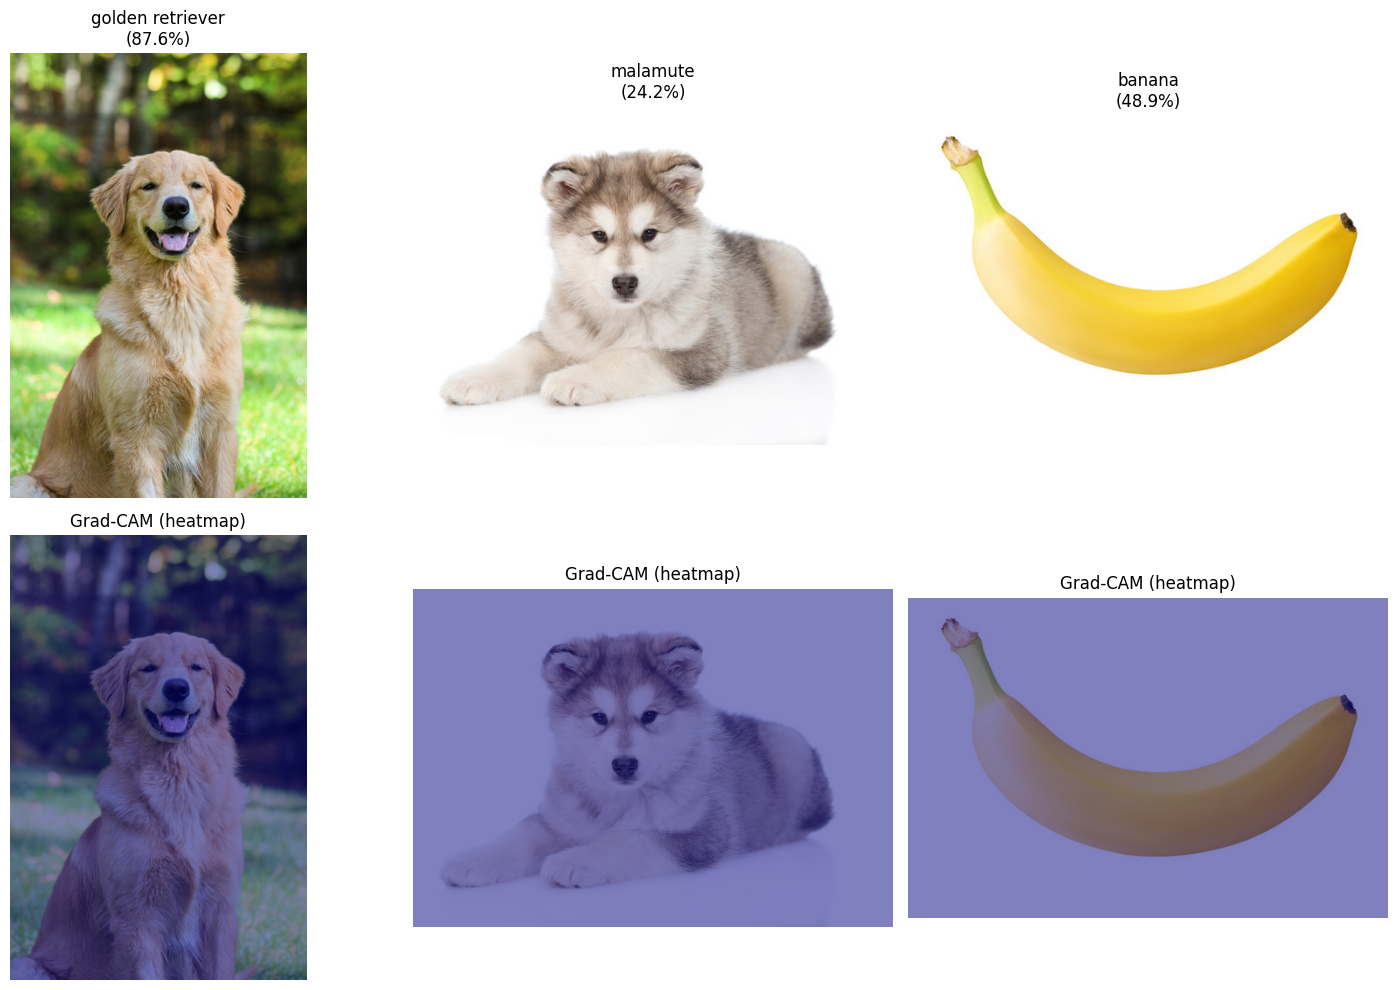

In [8]:
n = len(rutas_imagenes)
fig, ejes = plt.subplots(2, n, figsize=(5 * n, 10))
if n == 1:
    ejes = ejes.reshape(2, 1)

for col, ruta in enumerate(rutas_imagenes):
    imagen, resultados = predecir(ruta)
    _, heatmap = generar_heatmap(ruta)

    print(f"\nImagen: {ruta}")
    for etiqueta, prob in resultados:
        print(f"  {etiqueta:25s} {prob * 100:5.2f}%")

    etiqueta_top, prob_top = resultados[0]

    ejes[0, col].imshow(imagen)
    ejes[0, col].set_title(f"{etiqueta_top}\n({prob_top * 100:.1f}%)")
    ejes[0, col].axis("off")

    ejes[1, col].imshow(imagen)
    ejes[1, col].imshow(heatmap, cmap="jet", alpha=0.5)
    ejes[1, col].set_title("Grad-CAM (heatmap)")
    ejes[1, col].axis("off")

plt.tight_layout()
plt.show()